In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('faithful.csv')

In [ ]:
data

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85
...,...,...
267,4.117,81
268,2.150,46
269,4.417,90
270,1.817,46


In [ ]:
duration = data.eruptions

In [ ]:
waiting = data.waiting

In [ ]:
waiting

,waiting
0,79
1,54
2,74
3,62
4,85
...,...
267,81
268,46
269,90
270,46


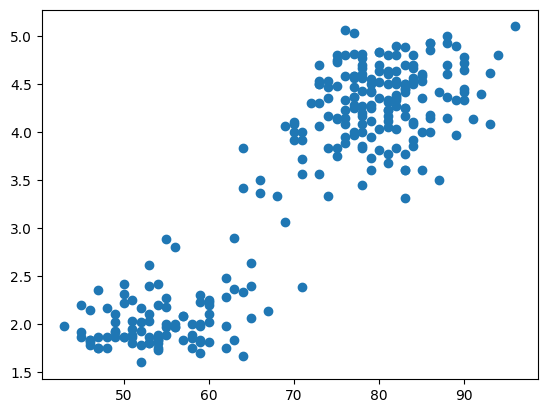

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(waiting, duration)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

# Reshape waiting to be a 2D array as required by sklearn
X = waiting.values.reshape(-1, 1)
y = duration

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Coefficient: 0.0756
Intercept: -1.8740


In [ ]:
model.predict([[75]])

array([3.79808011])

In [ ]:
y_predict = model.predict(X)

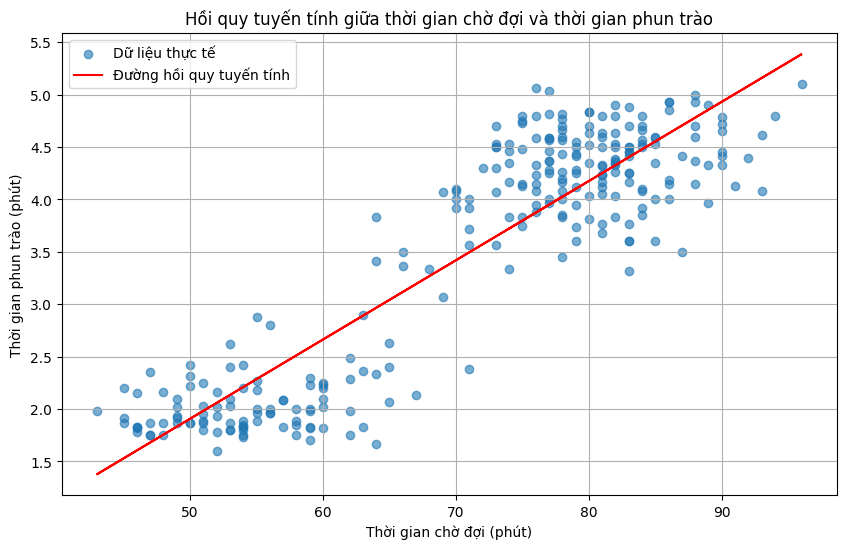

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Dữ liệu thực tế', alpha=0.6)
plt.plot(X, y_predict, color='red', label='Đường hồi quy tuyến tính')
plt.xlabel('Thời gian chờ đợi (phút)')
plt.ylabel('Thời gian phun trào (phút)')
plt.title('Hồi quy tuyến tính giữa thời gian chờ đợi và thời gian phun trào')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

In [ ]:
bloodpress = pd.read_csv('bloodpress.csv')

In [ ]:
weight = bloodpress.Weight

In [ ]:
press = bloodpress.BP

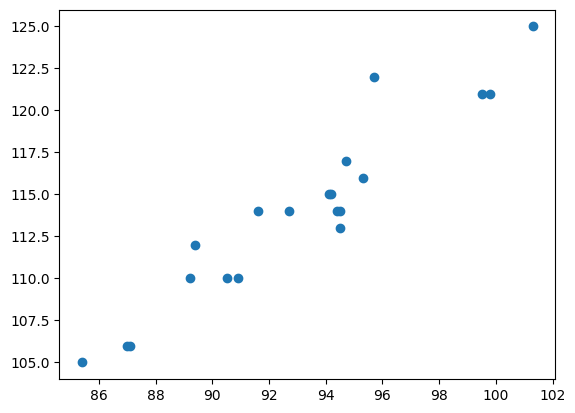

In [ ]:
plt.scatter(weight, press)
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

X = weight.values.reshape(-1, 1)
y = press

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print(f"Coefficient: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Coefficient: 1.2009
Intercept: 2.2053


In [ ]:
from sklearn.metrics import r2_score

# Calculate R-squared
r2 = r2_score(y, model.predict(X))
print(f"R-squared: {r2:.4f}")

R-squared: 0.9026


In [ ]:
age = bloodpress.Age

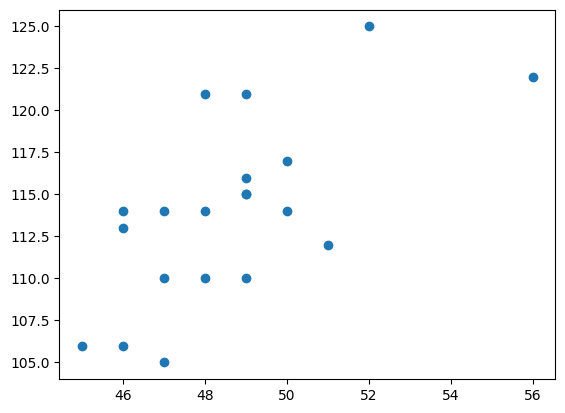

In [ ]:
plt.scatter(age,press)

In [ ]:
from sklearn.linear_model import LinearRegression

# Combine 'weight' and 'age' into a single DataFrame for features (X)
X_multi = bloodpress[['Weight', 'Age']]
y_multi = bloodpress['BP']

# Create and fit the linear regression model with multiple features
multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

# Print the coefficients and intercept
print(f"Coefficients (Weight, Age): {multi_model.coef_[0]:.4f}, {multi_model.coef_[1]:.4f}")
print(f"Intercept: {multi_model.intercept_:.4f}")

Coefficients (Weight, Age): 1.0330, 0.7083
Intercept: -16.5794


In [ ]:
from sklearn.metrics import r2_score

# Calculate R-squared
r2 = r2_score(y_multi, multi_model.predict(X_multi))
print(f"R-squared: {r2:.4f}")

R-squared: 0.9914


In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_multi, multi_model.predict(X_multi))
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.2412


In [ ]:
credit_student = pd.read_csv('credit_student.csv')

In [ ]:
credit_student

,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879
...,...,...,...,...,...
9995,9996,No,No,711.555020,52992.378914
9996,9997,No,No,757.962918,19660.721768
9997,9998,No,No,845.411989,58636.156984
9998,9999,No,No,1569.009053,36669.112365


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Prepare the data
X_logistic = credit_student[['student', 'balance', 'income']].copy()
y_logistic = credit_student['default']

# Encode the 'student' categorical variable
le = LabelEncoder()
X_logistic['student'] = le.fit_transform(X_logistic['student'])

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(solver='liblinear', random_state=42)
logistic_model.fit(X_logistic, y_logistic)

# Print the coefficients and intercept
print(f"Coefficients (student, balance, income): {logistic_model.coef_[0]}")
print(f"Intercept: {logistic_model.intercept_[0]}")

Coefficients (student, balance, income): [-2.51031353e-06  4.07583928e-04 -1.25881515e-04]
Intercept: -1.941796806247305e-06


In [ ]:
logistic_model.predict(X_logistic)

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)